In [ ]:
import polars as pl
from pathlib import Path
import json
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import numpy as np
from procompa import get_project_root



PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [2]:
benchmark_structure_similarity = pl.read_parquet(data_dir / "Pipeline/7_benchmark_part_one/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")

How well does stoic work

In [3]:
# for how many of the 59 complexes did stoic not find the correct stoichiometry
#X2_output = pl.read_parquet(data_dir/ "Pipeline/7_benchmark_part_one/cf_pdb_structure_similarity/aggregate_cf_for_pdb_eval.parquet")
#X2_output_known_stoi = X2_output.filter(pl.col("correct_pred_rank") != "unknown")

benchmark_structure_similarity_one_per_complex = benchmark_structure_similarity.sort("usalign_cpx_tm_score", descending=False).group_by("complex_ac").first()

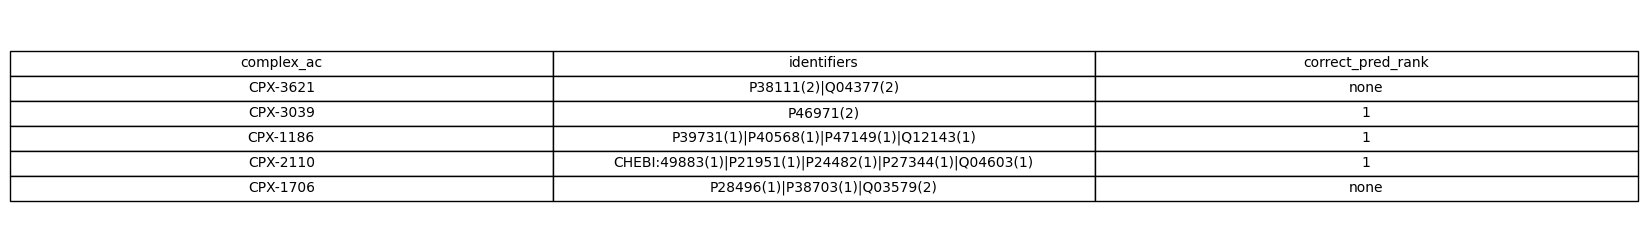

In [35]:
# did stoic get it gor complexes that werent in training 
#interesting complexes (so stoi interesting and n_prot >2)

cols = ["complex_ac","identifiers", "correct_pred_rank"]
table_df = benchmark_structure_similarity_one_per_complex.select(cols)

table_df = benchmark_structure_similarity_one_per_complex.filter(pl.col("pdb_with_identical_proteins_set_to_CF_in_stoic") == False).select(cols)

fig, ax = plt.subplots(figsize=(7 * len(cols), 0.4 * len(table_df) + 1))
ax.axis("off")

tab = ax.table(
    cellText=table_df.to_pandas().round(3).astype(str).values,
    colLabels=cols,
    cellLoc="center",
    loc="center",
)
tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1, 1.5)

#plt.savefig("cf_pdb_eval_table.png", dpi=300, bbox_inches="tight")


how much does the CF output differ

In [3]:
# add Cf output for eahc row
conf = {}
for d in {Path(p).parent for p in benchmark_structure_similarity["combfold_output_path"]}:
    conf.update(dict(line.split() for line in open(d / "confidence.txt")))

benchmark_structure_similarity = benchmark_structure_similarity.with_columns(pl.col("combfold_output_path").map_elements(lambda p: float(conf[p]), return_dtype=pl.Float64).alias("CF_confidence"))

In [6]:
benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    pl.col("CP_stochiometry").map_elements(lambda s: any(v > 1 for v in json.loads(s).values()), return_dtype=pl.Boolean).alias("interesting_stoichiometry")
)

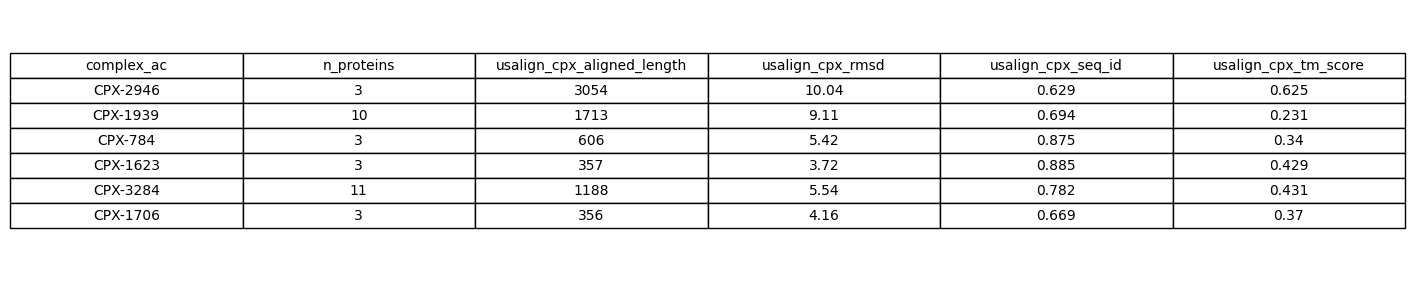

In [22]:
#interesting complexes (so stoi interesting and n_prot >2)

benchmark_structure_similarity_intr = (
    benchmark_structure_similarity
    .filter(
        (pl.col("interesting_stoichiometry") == True) &
        (pl.col("n_proteins") > 2)
    )
    .sort("usalign_cpx_tm_score", descending=False)
    .group_by("complex_ac")
    .first()
)

cols = ["complex_ac","n_proteins", "usalign_cpx_aligned_length", "usalign_cpx_rmsd", "usalign_cpx_seq_id", "usalign_cpx_tm_score"]

table_df = benchmark_structure_similarity_intr.select(cols)

fig, ax = plt.subplots(figsize=(3 * len(cols), 0.4 * len(table_df) + 1))
ax.axis("off")

tab = ax.table(
    cellText=table_df.to_pandas().round(3).astype(str).values,
    colLabels=cols,
    cellLoc="center",
    loc="center",
)
tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1, 1.5)

#plt.savefig("cf_pdb_eval_table.png", dpi=300, bbox_inches="tight")


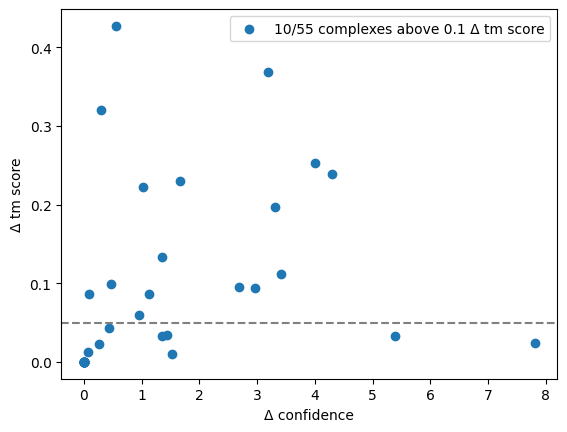

In [48]:
summary_tm_conf = benchmark_structure_similarity.group_by("complex_ac").agg(
    (pl.col("usalign_cpx_tm_score").max() - pl.col("usalign_cpx_tm_score").min()).alias("tm_score_range"),
    (pl.col("CF_confidence").max() - pl.col("CF_confidence").min()).alias("confidence_range"),
    pl.len().alias("n_outputs"),
).filter(pl.col("n_outputs") > 1)


n_above = (summary_tm_conf["tm_score_range"] > 0.1).sum()

plt.scatter(summary_tm_conf["confidence_range"], summary_tm_conf["tm_score_range"])
plt.axhline(0.05, color="grey", linestyle="--")
plt.ylabel("Δ tm score")
plt.xlabel("Δ confidence")
n_total = summary_tm_conf.height
plt.legend([f"{n_above}/{n_total} complexes above 0.1 Δ tm score"])
plt.show()

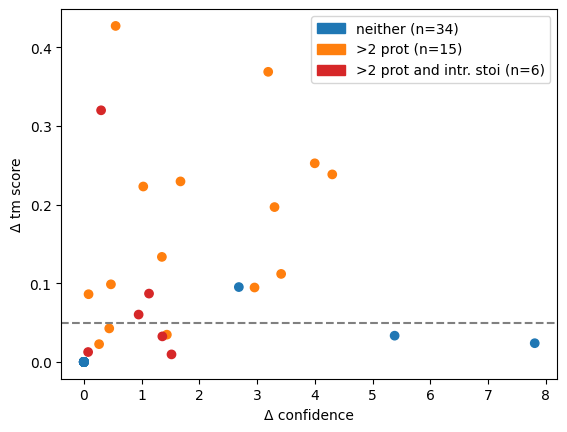

In [47]:
summary_tm_conf = benchmark_structure_similarity.group_by("complex_ac").agg(
    (pl.col("usalign_cpx_tm_score").max() - pl.col("usalign_cpx_tm_score").min()).alias("tm_score_range"),
    (pl.col("CF_confidence").max() - pl.col("CF_confidence").min()).alias("confidence_range"),
    pl.len().alias("n_outputs"),
    (pl.col("n_proteins").first() > 2).alias("many_proteins"),
    pl.col("interesting_stoichiometry").first().alias("interesting_stoichiometry"),
).filter(pl.col("n_outputs") > 1)

n_above = (summary_tm_conf["tm_score_range"] > 0.1).sum()
n_total = summary_tm_conf.height

summary_tm_conf = summary_tm_conf.with_columns(
    pl.when(pl.col("many_proteins") & pl.col("interesting_stoichiometry"))
    .then(pl.lit("both"))
    .when(pl.col("many_proteins"))
    .then(pl.lit("many proteins"))
    .otherwise(pl.lit("neither"))
    .alias("category")
)

cmap = {"neither": "tab:blue", "many proteins": "tab:orange", "both": "tab:red"}
order = ["neither", "many proteins", "both"]
counts = dict(zip(*summary_tm_conf["category"].value_counts().to_dict(as_series=False).values()))



labels = {"neither": "neither", "many proteins": ">2 prot", "both": ">2 prot and intr. stoi"}

fig, ax = plt.subplots()
ax.scatter(
    summary_tm_conf["confidence_range"],
    summary_tm_conf["tm_score_range"],
    c=[cmap[c] for c in summary_tm_conf["category"]],
)
ax.axhline(0.05, color="grey", linestyle="--")
ax.set_ylabel("Δ tm score")
ax.set_xlabel("Δ confidence")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=cmap[cat], label=f"{labels[cat]} (n={counts.get(cat, 0)})") for cat in order
])
plt.show()



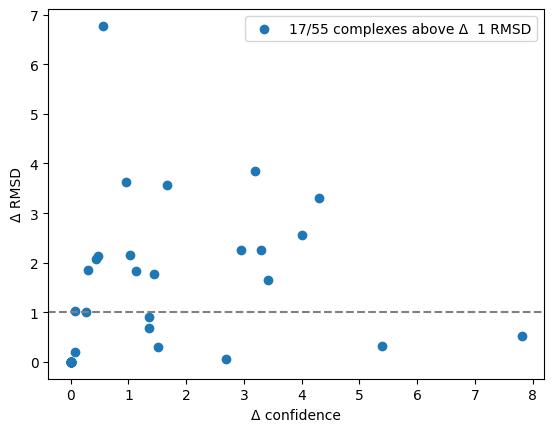

In [51]:
summary_rmsd_conf = benchmark_structure_similarity.group_by("complex_ac").agg(
    (pl.col("usalign_cpx_rmsd").max() - pl.col("usalign_cpx_rmsd").min()).alias("rmsd_score_range"),
    (pl.col("CF_confidence").max() - pl.col("CF_confidence").min()).alias("confidence_range"),
    pl.len().alias("n_outputs"),
).filter(pl.col("n_outputs") > 1)

n_above = (summary_rmsd_conf["rmsd_score_range"] > 1).sum()

plt.scatter(summary_rmsd_conf["confidence_range"], summary_rmsd_conf["rmsd_score_range"])
plt.axhline(1, color="grey", linestyle="--")
plt.xlabel("Δ confidence")
plt.ylabel("Δ RMSD")
n_total = summary_rmsd_conf.height
plt.legend([f"{n_above}/{n_total} complexes above Δ  1 RMSD"])
plt.show()

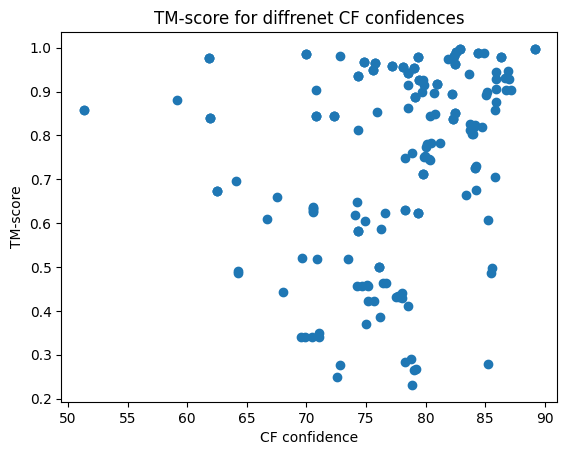

In [ ]:
plt.scatter(benchmark_structure_similarity["CF_confidence"], benchmark_structure_similarity["usalign_cpx_tm_score"])
plt.xlabel("CF confidence")
plt.ylabel("TM-score")
plt.title("TM-scores for different CF confidence levels")
plt.show()

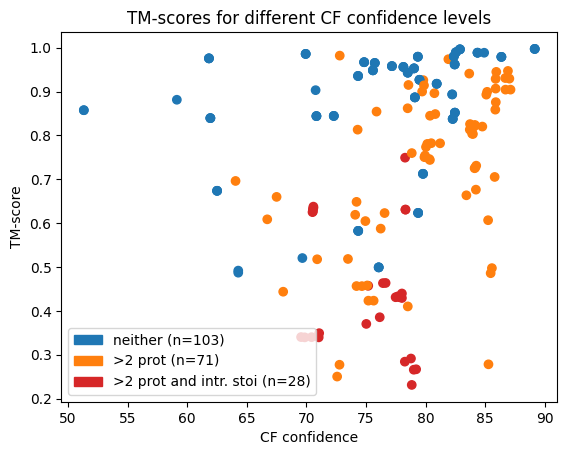

In [53]:
plot_df = benchmark_structure_similarity.with_columns(
    (pl.col("n_proteins") > 2).alias("many_proteins"),
).with_columns(
    pl.when(pl.col("many_proteins") & pl.col("interesting_stoichiometry"))
    .then(pl.lit("both"))
    .when(pl.col("many_proteins"))
    .then(pl.lit("many proteins"))
    .otherwise(pl.lit("neither"))
    .alias("category")
)

cmap = {"neither": "tab:blue", "many proteins": "tab:orange", "both": "tab:red"}
labels = {"neither": "neither", "many proteins": ">2 prot", "both": ">2 prot and intr. stoi"}
order = ["neither", "many proteins", "both"]
counts = dict(zip(*plot_df["category"].value_counts().to_dict(as_series=False).values()))

fig, ax = plt.subplots()
ax.scatter(
    plot_df["CF_confidence"],
    plot_df["usalign_cpx_tm_score"],
    c=[cmap[c] for c in plot_df["category"]],
)
ax.set_xlabel("CF confidence")
ax.set_ylabel("TM-score")
ax.set_title("TM-scores for different CF confidence levels")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=cmap[cat], label=f"{labels[cat]} (n={counts.get(cat, 0)})") for cat in order
])
plt.show()

In [ ]:
plt.scatter(benchmark_structure_similarity["CF_confidence"], benchmark_structure_similarity["usalign_cpx_rmsd"])
plt.xlabel("CF confidence")
plt.ylabel("RMSD-score")
plt.title("RMSD-scores for different CF confidence levels")
plt.show()

how does TM behave for differntly sized complexes

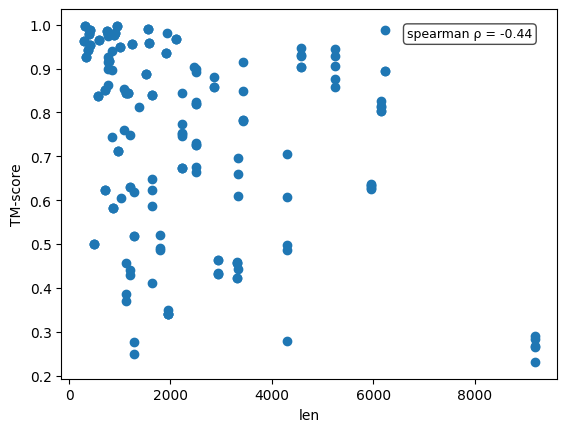

In [9]:
from scipy.stats import spearmanr, pearsonr

x_vals = benchmark_structure_similarity["usalign_cpx_len_structure1"].to_numpy()
y_vals = benchmark_structure_similarity["usalign_cpx_tm_score"].to_numpy()

mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
x_clean, y_clean = x_vals[mask], y_vals[mask]

rho_s, p_s = spearmanr(x_clean, y_clean)
rho_p, p_p = pearsonr(x_clean, y_clean)

plt.scatter(x_vals, y_vals)
plt.xlabel("len")
plt.ylabel("TM-score")
plt.text(
    0.95, 0.95, f"spearman ρ = {rho_s:.2f}",
    transform=plt.gca().transAxes, ha="right", va="top",
    fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)
plt.show()

In [3]:
"""
n_proteins_bucketed = pl.when(pl.col("n_proteins") >= 7).then(7).otherwise(pl.col("n_proteins"))

stats = benchmark_structure_similarity.filter(pl.col("n_proteins") > 1).with_columns(
    n_proteins_bucketed.alias("n_proteins_group")
).group_by("n_proteins_group").agg(
    pl.len().alias("n_outputs"),
    pl.col("complex_ac").n_unique().alias("n_complexes"),
).sort("n_proteins_group")

df_bucketed = benchmark_structure_similarity.filter(pl.col("n_proteins") > 1).with_columns(n_proteins_bucketed.alias("n_proteins_group"))
groups = [df_bucketed.filter(pl.col("n_proteins_group") == n)["usalign_cpx_tm_score"] for n in stats["n_proteins_group"]]
labels = [f"{'7+' if n == 7 else n}\n({o} outputs, {c} complexes)" for n, o, c in zip(stats["n_proteins_group"], stats["n_outputs"], stats["n_complexes"])]

plt.figure(figsize=(16, 6))
plt.boxplot(groups, tick_labels=labels)
plt.xlabel("n_proteins")
plt.ylabel("TM-score")
plt.show()
"""

'\nn_proteins_bucketed = pl.when(pl.col("n_proteins") >= 7).then(7).otherwise(pl.col("n_proteins"))\n\nstats = benchmark_structure_similarity.filter(pl.col("n_proteins") > 1).with_columns(\n    n_proteins_bucketed.alias("n_proteins_group")\n).group_by("n_proteins_group").agg(\n    pl.len().alias("n_outputs"),\n    pl.col("complex_ac").n_unique().alias("n_complexes"),\n).sort("n_proteins_group")\n\ndf_bucketed = benchmark_structure_similarity.filter(pl.col("n_proteins") > 1).with_columns(n_proteins_bucketed.alias("n_proteins_group"))\ngroups = [df_bucketed.filter(pl.col("n_proteins_group") == n)["usalign_cpx_tm_score"] for n in stats["n_proteins_group"]]\nlabels = [f"{\'7+\' if n == 7 else n}\n({o} outputs, {c} complexes)" for n, o, c in zip(stats["n_proteins_group"], stats["n_outputs"], stats["n_complexes"])]\n\nplt.figure(figsize=(16, 6))\nplt.boxplot(groups, tick_labels=labels)\nplt.xlabel("n_proteins")\nplt.ylabel("TM-score")\nplt.show()\n'

Tm scores for all outputs, hightlight the ones where stoi is intresting

Are pairs closeby

In [4]:
import json

def make_pair_simple(key: str) -> frozenset:
    a, b = key.split("_")
    return frozenset([a, b])

def pairset(d) -> set[frozenset]:
    if isinstance(d, str):
        d = json.loads(d)
    return {make_pair_simple(k) for k in d}

def compare_chainpairs_row(cf_dict, ref_dict) -> dict:
    cf_pairs = pairset(cf_dict)
    ref_pairs = pairset(ref_dict)
    return {
        "n_cf": len(cf_pairs),
        "n_ref": len(ref_pairs),
        "n_cf_in_ref": len(cf_pairs & ref_pairs),
        "n_cf_extra": len(cf_pairs - ref_pairs),
        "n_ref_missing": len(ref_pairs - cf_pairs),
    }

In [5]:
benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    pl.struct(["cf_close_by_chainpairs", "ref_close_by_chainpairs"])
    .map_elements(
        lambda row: compare_chainpairs_row(
            row["cf_close_by_chainpairs"], row["ref_close_by_chainpairs"]
        ),
        return_dtype=pl.Struct({
            "n_cf": pl.UInt32,
            "n_ref": pl.UInt32,
            "n_cf_in_ref": pl.UInt32,
            "n_cf_extra": pl.UInt32,
            "n_ref_missing": pl.UInt32,
        }),
    )
    .alias("chainpair_overlap")
).unnest("chainpair_overlap")

# add jaccard
benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    (
        pl.col("n_cf_in_ref")
        / (pl.col("n_cf_in_ref") + pl.col("n_cf_extra") + pl.col("n_ref_missing"))
    ).alias("jaccard")
)

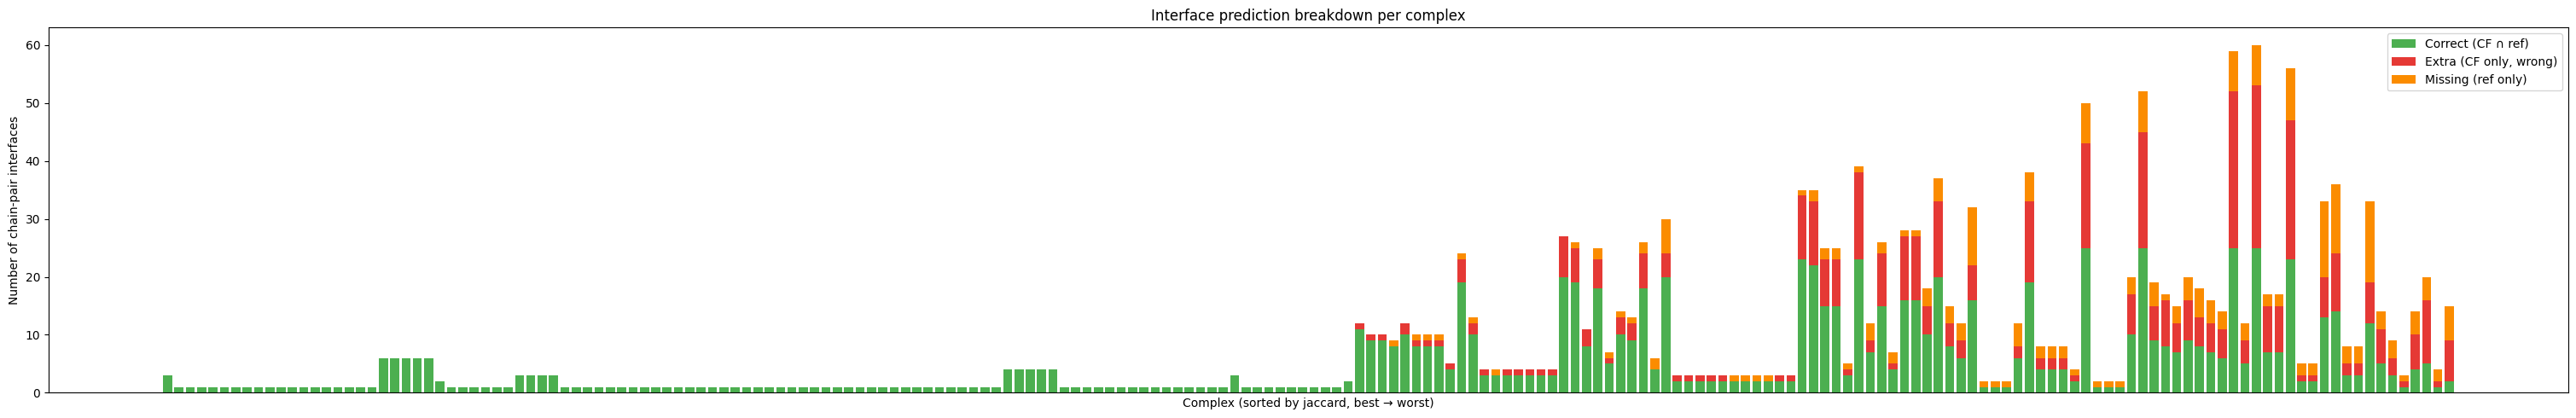

In [ ]:
df = benchmark_structure_similarity.sort("jaccard", descending=True)

n = len(df)
x = np.arange(n)

fig, ax = plt.subplots(figsize=(max(10, n * 0.15), 5))

# Stacked bars: correctly predicted (green), extra/wrong (red), missing (orange)
ax.bar(x, df["n_cf_in_ref"], color="#4CAF50", label="Correct (CF ∩ ref)")
ax.bar(x, df["n_cf_extra"], bottom=df["n_cf_in_ref"], color="#E53935", label="Extra (CF only, wrong)")
ax.bar(x, df["n_ref_missing"], bottom=df["n_cf_in_ref"] + df["n_cf_extra"],
       color="#FB8C00", label="Missing (ref only)")

ax.set_xlabel("Complex (sorted by jaccard, best → worst)")
ax.set_ylabel("Number of chain-pair interfaces")
ax.set_title("Interface prediction breakdown per complex")
ax.legend()
ax.set_xticks([])  

plt.tight_layout()
plt.show()

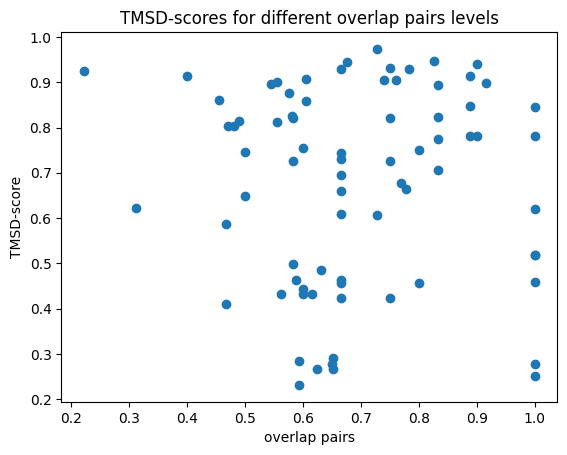

In [53]:
benchmark_structure_similarity_bigger_complexes = benchmark_structure_similarity.filter(pl.col("n_proteins")>3)
plt.scatter(benchmark_structure_similarity_bigger_complexes["overlap_pairs"], benchmark_structure_similarity_bigger_complexes["usalign_cpx_tm_score"])
plt.xlabel("overlap pairs")
plt.ylabel("TMSD-score")
plt.title("TMSD-scores for different overlap pairs levels")
plt.show()

In [ ]:
#filter for complexes that have more than 2 proteins are same pairs placed closeby

Add Af metrics

In [60]:
bench_part_one_metrics = pl.read_csv(data_dir/"Pipeline/7_benchmark_part_one/7_benchmark_part_one_pool_pairs_metrics_with_plddt.csv")

In [61]:
# only add homodimer pair, if the stoi was bigger 2
stoich_by_complex = benchmark_structure_similarity.select("complex_ac", "CP_stochiometry").unique()

def is_real_homodimer(r):
    if r["CP_stochiometry"] is None:
        return False
    return json.loads(r["CP_stochiometry"]).get(r["protein1"], 0) >= 2

bench_part_one_metrics = bench_part_one_metrics.join(stoich_by_complex, on="complex_ac", how="left").with_columns(
    pl.struct(["protein1", "CP_stochiometry"]).map_elements(is_real_homodimer, return_dtype=pl.Boolean).alias("is_real_homodimer")
).filter((pl.col("pair_type") != "homo") | pl.col("is_real_homodimer"))


metrics_by_complex = bench_part_one_metrics.group_by("complex_ac").agg(
    pl.col("pair").alias("af_pairs"),
    pl.col("chain_pair_iptm").alias("chain_pair_iptm"),
    pl.col("chain_pair_pae_min_min").alias("chain_pair_pae_min_min"),
    pl.col("chain_pair_pae_min_max").alias("chain_pair_pae_min_max"),
    pl.col("chain_pair_pae_min_mean").alias("chain_pair_pae_min_mean"),
    pl.col("plddt1").alias("plddt1"),
    pl.col("plddt2").alias("plddt2"),
)

benchmark_structure_similarity = benchmark_structure_similarity.join(metrics_by_complex, on="complex_ac", how="left")

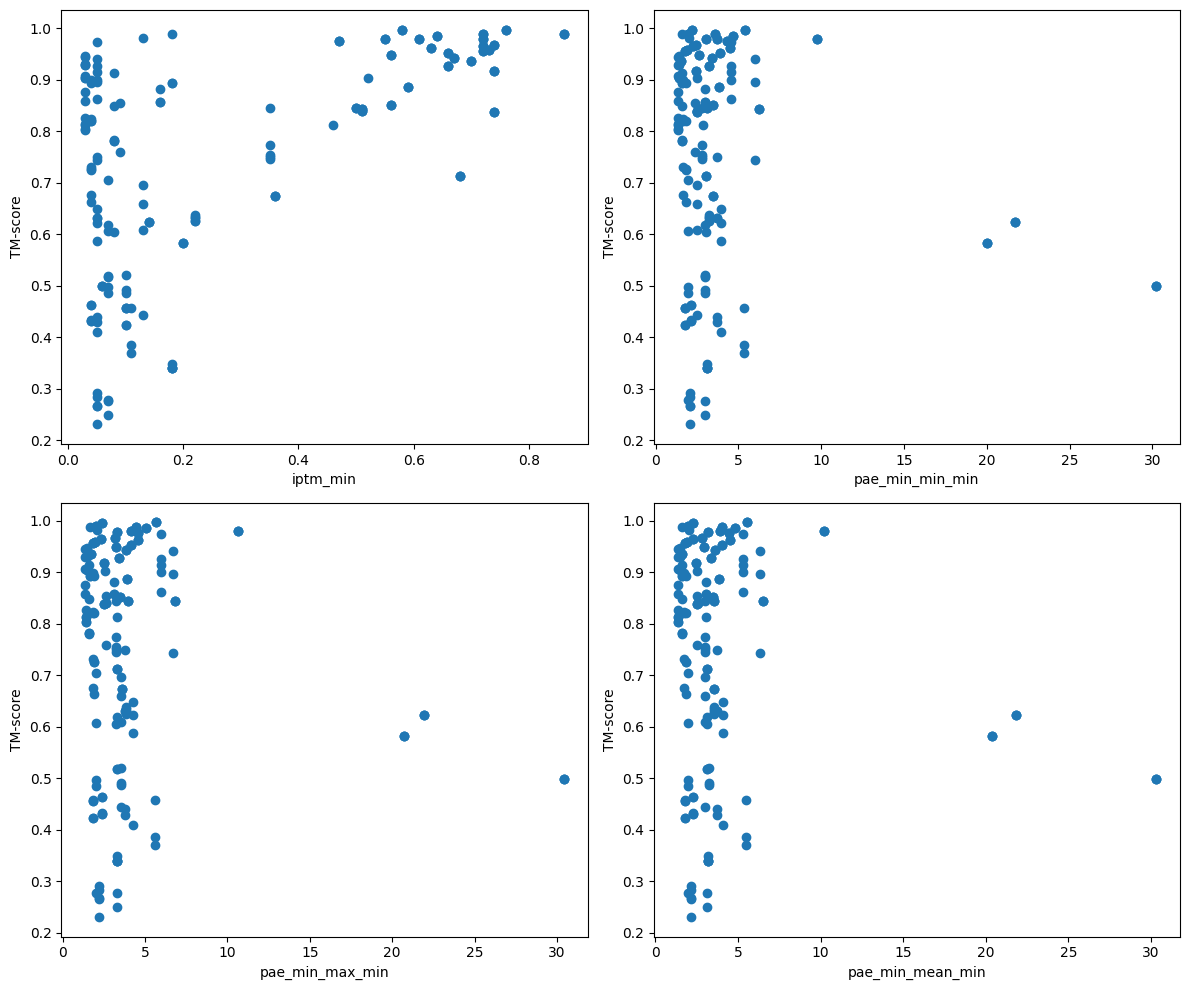

In [59]:
benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    pl.col("chain_pair_iptm").list.min().alias("iptm_min"),
    pl.col("chain_pair_pae_min_min").list.min().alias("pae_min_min_min"),
    pl.col("chain_pair_pae_min_max").list.min().alias("pae_min_max_min"),
    pl.col("chain_pair_pae_min_mean").list.min().alias("pae_min_mean_min"),
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, x in zip(axes.flat, ["iptm_min", "pae_min_min_min", "pae_min_max_min", "pae_min_mean_min"]):
    ax.scatter(benchmark_structure_similarity[x], benchmark_structure_similarity["usalign_cpx_tm_score"])
    ax.set_xlabel(x)
    ax.set_ylabel("TM-score")
plt.tight_layout()
plt.show()

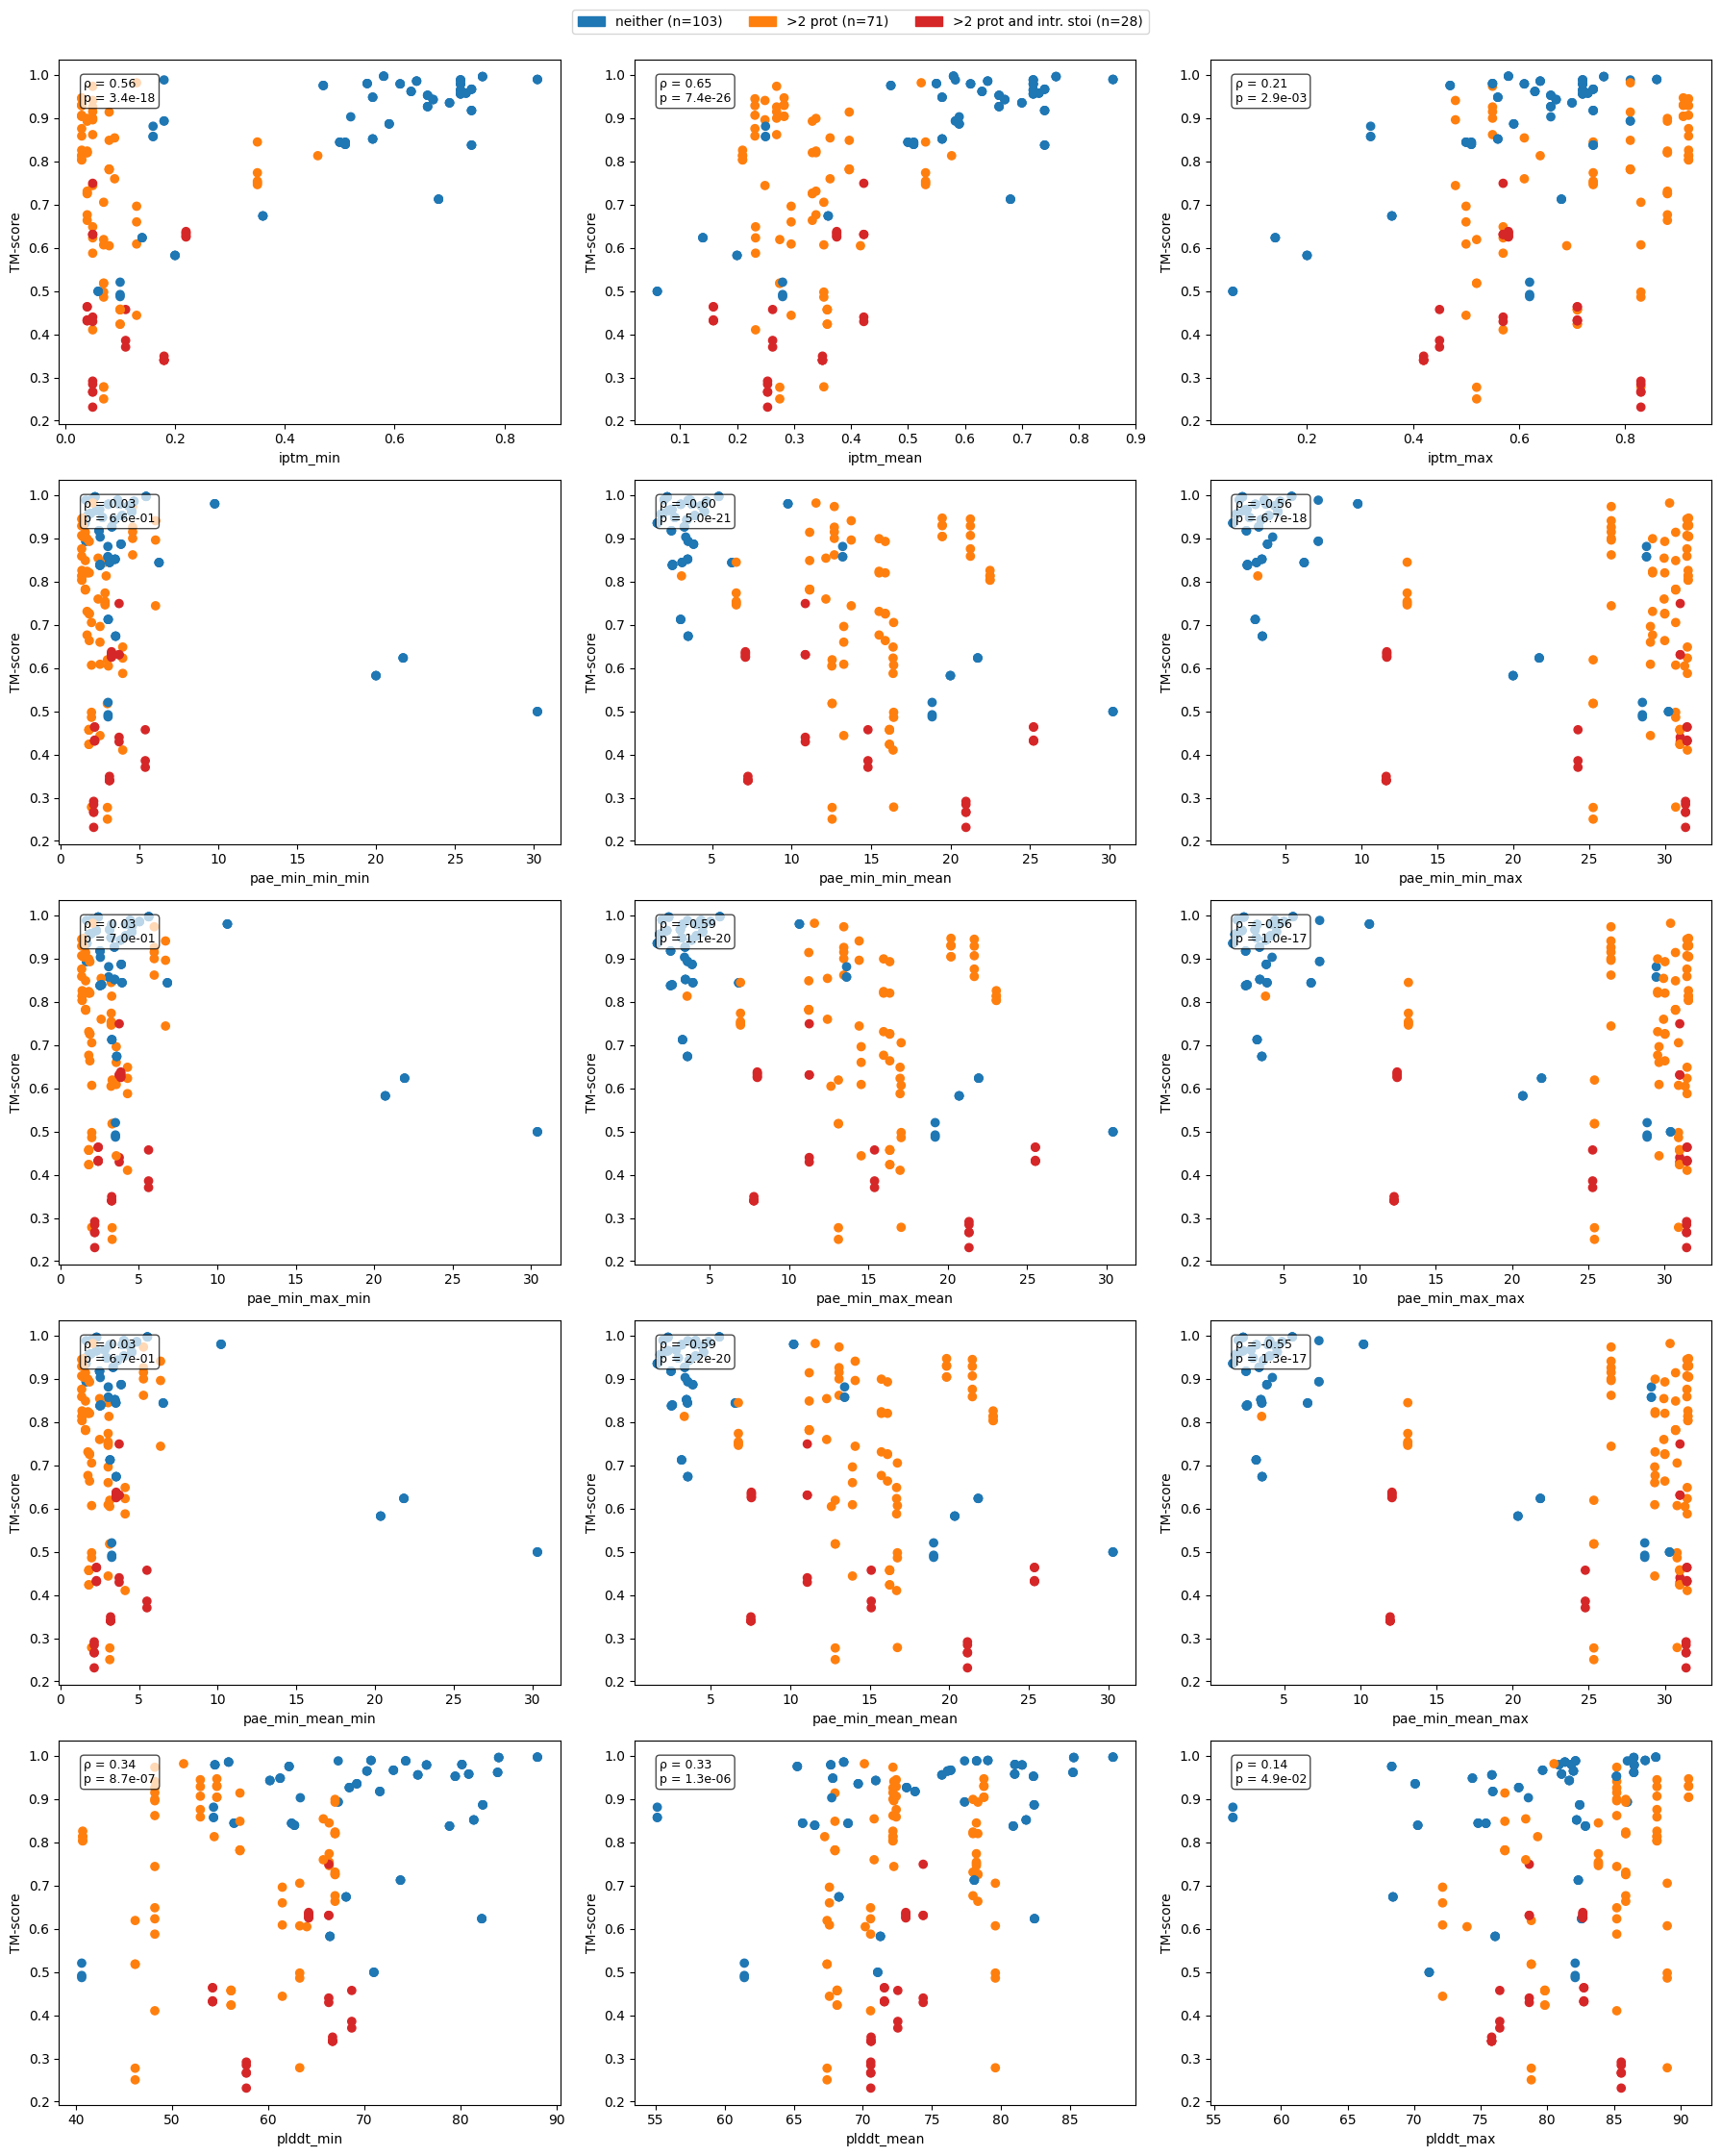

In [68]:
base_cols = {
    "iptm": pl.col("chain_pair_iptm"),
    "pae_min_min": pl.col("chain_pair_pae_min_min"),
    "pae_min_max": pl.col("chain_pair_pae_min_max"),
    "pae_min_mean": pl.col("chain_pair_pae_min_mean"),
    "plddt": pl.concat_list(["plddt1", "plddt2"]),
}

aggs = {"min": "min", "mean": "mean", "max": "max"}

benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    [
        getattr(expr.list, agg_method)().alias(f"{name}_{agg_name}")
        for name, expr in base_cols.items()
        for agg_name, agg_method in aggs.items()
    ]
)

metrics = [f"{name}_{agg_name}" for name in base_cols for agg_name in aggs]

from scipy.stats import spearmanr
from matplotlib.patches import Patch

benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    (pl.col("n_proteins") > 2).alias("many_proteins"),
).with_columns(
    pl.when(pl.col("many_proteins") & pl.col("interesting_stoichiometry"))
    .then(pl.lit("both"))
    .when(pl.col("many_proteins"))
    .then(pl.lit("many proteins"))
    .otherwise(pl.lit("neither"))
    .alias("category")
)

cmap = {"neither": "tab:blue", "many proteins": "tab:orange", "both": "tab:red"}
labels = {"neither": "neither", "many proteins": ">2 prot", "both": ">2 prot and intr. stoi"}
order = ["neither", "many proteins", "both"]
counts = dict(zip(*benchmark_structure_similarity["category"].value_counts().to_dict(as_series=False).values()))

colors = [cmap[c] for c in benchmark_structure_similarity["category"]]

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
for ax, x in zip(axes.flat, metrics):
    x_vals = benchmark_structure_similarity[x].to_numpy()
    y_vals = benchmark_structure_similarity["usalign_cpx_tm_score"].to_numpy()

    mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
    rho, pval = spearmanr(x_vals[mask], y_vals[mask])

    ax.scatter(x_vals, y_vals, c=colors)
    ax.set_xlabel(x)
    ax.set_ylabel("TM-score")
    ax.text(
        0.05, 0.95, f"ρ = {rho:.2f}\np = {pval:.1e}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
    )

fig.legend(
    handles=[Patch(color=cmap[cat], label=f"{labels[cat]} (n={counts.get(cat, 0)})") for cat in order],
    loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3,
)
plt.tight_layout()
plt.show()

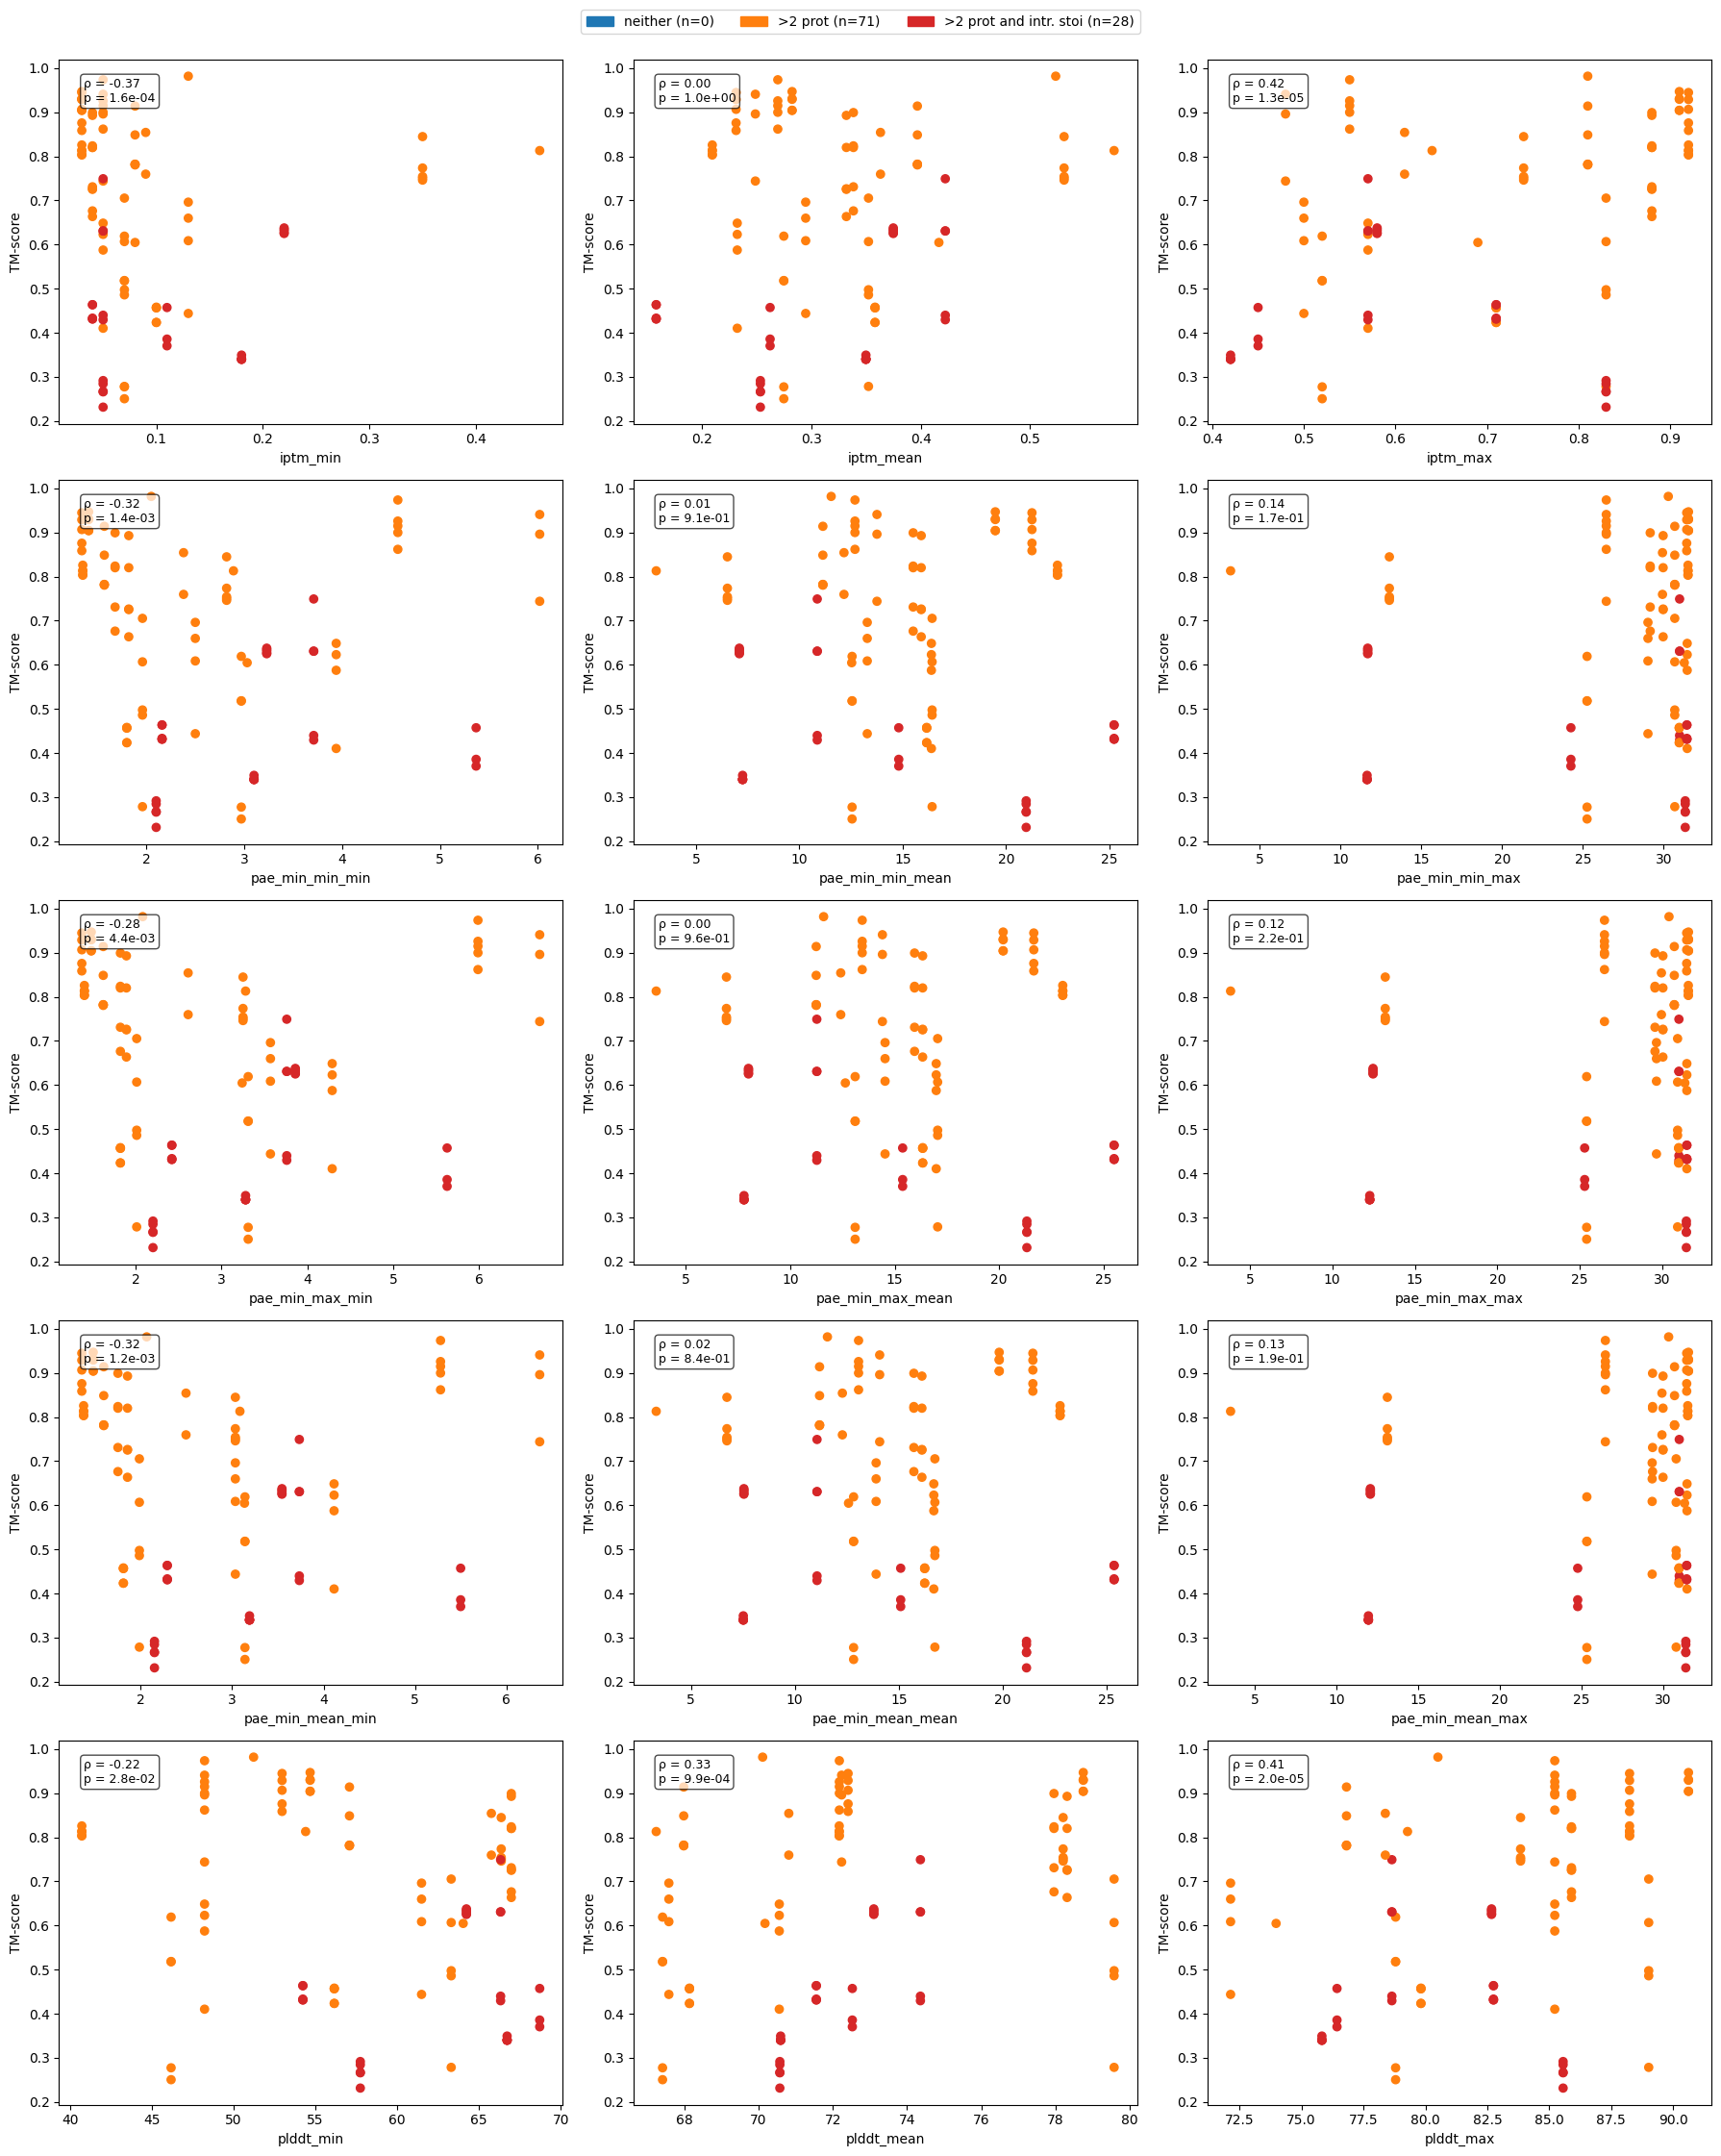

In [69]:
from scipy.stats import spearmanr
from matplotlib.patches import Patch

plot_df = benchmark_structure_similarity.filter(pl.col("n_proteins") > 2)

counts = dict(zip(*plot_df["category"].value_counts().to_dict(as_series=False).values()))
colors = [cmap[c] for c in plot_df["category"]]

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
for ax, x in zip(axes.flat, metrics):
    x_vals = plot_df[x].to_numpy()
    y_vals = plot_df["usalign_cpx_tm_score"].to_numpy()

    mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
    rho, pval = spearmanr(x_vals[mask], y_vals[mask])

    ax.scatter(x_vals, y_vals, c=colors)
    ax.set_xlabel(x)
    ax.set_ylabel("TM-score")
    ax.text(
        0.05, 0.95, f"ρ = {rho:.2f}\np = {pval:.1e}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
    )

fig.legend(
    handles=[Patch(color=cmap[cat], label=f"{labels[cat]} (n={counts.get(cat, 0)})") for cat in order],
    loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3,
)
plt.tight_layout()
plt.show()